<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Tarea5_CHURAcutipa_UHI_Arequipa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA: Isla de Calor Urbana — Arequipa
## Ciencia de Datos Ambientales | UTEC

**Basado en:** Lab6_Ses3_IslaCalor_GEE (Lima Metropolitana)
**Ciudad elegida:** Arequipa — ciudad andina árida, 2,335 m s.n.m.
**Comparación:** época seca (jun-ago) vs. verano austral (ene-mar), años 2025 y 2026 (FEN)

**Integrantes del grupo:** _Carrión Nicole, Churacutipa Lourdes, Mantari Rocio, Vila Julia,_

---

### Nota metodológica sobre el AOI (urbano/periurbano)

A diferencia del ejemplo de Lima (que usaba una provincia entera como "zona urbana" y otra
provincia vecina como "zona periurbana"), aquí usamos un criterio más preciso:

1. **GAUL** nos da el límite administrativo de la **provincia de Arequipa** (nuestra AOI).
2. **MapBiomas Perú (Colección 3)** nos dice, píxel por píxel (30 m), qué hay realmente
   construido dentro de ese límite: usamos la clase **ID 24 = "Infraestructura urbana"**.
3. `zona_urbana` = píxeles clase 24 dentro de la provincia de Arequipa.
   `zona_periurbana` = píxeles NO urbanos (agrícola, matorral, afloramiento rocoso, etc.)
   dentro de la misma provincia — es decir, la periferia real, no una provincia distinta.

> **Supuesto:** MapBiomas Perú Colección 3 cubre hasta el año 2024 (banda `classification_2024`).
> Aún no existe banda 2025/2026, así que usamos 2024 como huella urbana de referencia — la
> forma construida de la ciudad no cambia de forma relevante en 1-2 años, así que sigue siendo
> válida para enmascarar las imágenes LST de 2025-2026.


---
## 1. Configuración de Google Earth Engine

In [1]:
# Autenticación y conexión a GEE
import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    ee.Initialize(project="ee-lchuracutipa")
except Exception:
    ee.Authenticate()
    ee.Initialize(project="ee-lchuracutipa")

print("GEE conectado correctamente")

GEE conectado correctamente


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


---
## 2. Área de estudio — Provincia de Arequipa (Entregable 1)

Usamos **FAO GAUL** (igual que en el ejemplo de Lima) para delimitar la provincia,
y **MapBiomas Perú Col. 3** para distinguir urbano vs. periurbano dentro de ella.


In [2]:
# Provincia de Arequipa — límites FAO GAUL Simplified 500m
gaul_l2 = (ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level2")
    .filter(ee.Filter.eq("ADM0_NAME", "Peru")))

provincia_arequipa_fc = (gaul_l2
    .filter(ee.Filter.eq("ADM1_NAME", "Arequipa"))
    .filter(ee.Filter.eq("ADM2_NAME", "Arequipa")))

provincia_arequipa = provincia_arequipa_fc.geometry()

area_km2 = provincia_arequipa.area().divide(1e6).getInfo()
print(f"Provincia de Arequipa: {area_km2:.0f} km²")

Provincia de Arequipa: 10438 km²


In [3]:
# MapBiomas Perú Colección 3 — huella urbana (clase 24 = Infraestructura urbana)
mapbiomas = ee.Image(
    "projects/mapbiomas-public/assets/peru/collection3/mapbiomas_peru_collection3_integration_v1"
)

BANDA_ANIO = "classification_2024"          # último año disponible en la Col. 3
CLASE_URBANA = 24                            # Infraestructura urbana (leyenda MapBiomas Perú Col. 3)

cobertura = mapbiomas.select(BANDA_ANIO).clip(provincia_arequipa)

urbano_mask = cobertura.eq(CLASE_URBANA)          # 1 = urbano, 0/masked = resto
periurbano_mask = cobertura.neq(CLASE_URBANA)     # todo lo NO urbano dentro de la provincia

# Área urbana detectada por MapBiomas (para verificar que el criterio tiene sentido)
area_urbana_km2 = (urbano_mask.selfMask()
    .multiply(ee.Image.pixelArea())
    .reduceRegion(ee.Reducer.sum(), provincia_arequipa, 30, maxPixels=1e10)
    .get(BANDA_ANIO).getInfo())
print(f"Área urbana (MapBiomas, clase 24) dentro de la provincia: {area_urbana_km2/1e6:.1f} km²")

Área urbana (MapBiomas, clase 24) dentro de la provincia: 187.8 km²


In [4]:
# Mapa de ubicación — AOI + huella urbana MapBiomas
Map0 = geemap.Map(center=[-16.4, -71.53], zoom=10, basemap="Esri.WorldTopoMap")
Map0.addLayer(provincia_arequipa, {"color": "gray"}, "Provincia de Arequipa (GAUL)")
Map0.addLayer(urbano_mask.selfMask(), {"palette": ["red"]}, "Zona urbana (MapBiomas clase 24)")
Map0.addLayer(periurbano_mask.selfMask(), {"palette": ["green"]}, "Zona periurbana (MapBiomas, resto)")
Map0

Map(center=[-16.4, -71.53], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

---
## 3. Fuente 1 — Landsat 8/9: Temperatura Superficial a 30 m

**Producto:** `LANDSAT/LC08/C02/T1_L2` y `LANDSAT/LC09/C02/T1_L2`

$$T_{\text{°C}} = (DN \times 0.00341802 + 149.0) - 273.15$$

Analizamos dos composiciones para **2025 y 2026**:
- **Verano austral** (ene-mar) → Entregable 2
- **Época seca** (jun-ago) → Entregable 3


In [5]:
# Función para convertir ST_B10 a °C y enmascarar nubes
def procesar_landsat(img):
    qa = img.select("QA_PIXEL")
    mascara = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
    lst = (img.select("ST_B10")
              .multiply(0.00341802)
              .add(149.0)
              .subtract(273.15)
              .updateMask(mascara)
              .rename("LST_C"))
    return lst.copyProperties(img, ["system:time_start"])

l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

def landsat_composite(mes_ini, mes_fin, anio_ini, anio_fin):
    col = (l8.merge(l9)
        .filterBounds(provincia_arequipa)
        .filter(ee.Filter.calendarRange(mes_ini, mes_fin, "month"))
        .filter(ee.Filter.calendarRange(anio_ini, anio_fin, "year"))
        .filter(ee.Filter.lt("CLOUD_COVER", 30))
        .map(procesar_landsat))
    n = col.size().getInfo()
    return col.median(), n

# Verano (ene-mar) 2025-2026
landsat_verano, n_verano = landsat_composite(1, 3, 2025, 2026)
print(f"Imágenes Landsat verano 2025-2026: {n_verano}")

# Época seca (jun-ago) 2025-2026
landsat_seca, n_seca = landsat_composite(6, 8, 2025, 2026)
print(f"Imágenes Landsat época seca 2025-2026: {n_seca}")

Imágenes Landsat verano 2025-2026: 35
Imágenes Landsat época seca 2025-2026: 46


### 3.1 Mapa LST — Verano (Entregable 2)

In [6]:
vis_lst = {"min": 5, "max": 40, "palette": [
    "040274","040281","0502a3","0502b8","0602ff",
    "235cb1","307ef3","269db1","30c8e2","32d3ef",
    "3be285","3ff38f","86e26f","3ae237","b5e22e",
    "d6e21f","fff705","ffd611","ffb613","ff8b13",
    "ff6e08","ff500d","ff0000","de0101","c21301"
]}

Map1 = geemap.Map(center=[-16.4, -71.53], zoom=11, basemap="Esri.WorldTopoMap")
Map1.addLayer(landsat_verano.clip(provincia_arequipa), vis_lst, "LST Landsat 30m — Verano 2025-2026")
Map1.addLayer(urbano_mask.selfMask(), {"palette": ["red"]}, "Zona urbana (MapBiomas)")
Map1.add_colorbar(vis_lst, label="Temperatura superficial (°C)")
Map1

Map(center=[-16.4, -71.53], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [7]:
# Tabla UHI — Verano
def uhi_tabla(imagen, escala, etiqueta):
    urb = (imagen.updateMask(urbano_mask)
           .reduceRegion(ee.Reducer.mean(), provincia_arequipa, escala, maxPixels=1e10)
           .get("LST_C").getInfo())
    peri = (imagen.updateMask(periurbano_mask)
           .reduceRegion(ee.Reducer.mean(), provincia_arequipa, escala, maxPixels=1e10)
           .get("LST_C").getInfo())
    uhi = urb - peri if urb is not None and peri is not None else None
    print(f"{etiqueta:25s} Urbana: {urb:6.2f} °C   Periurbana: {peri:6.2f} °C   UHI: {uhi:+.2f} °C")
    return {"periodo": etiqueta, "urbana_C": urb, "periurbana_C": peri, "UHI_C": uhi}

fila_verano = uhi_tabla(landsat_verano, 30, "Verano 2025-2026 (Landsat)")

Verano 2025-2026 (Landsat) Urbana:  35.62 °C   Periurbana:  37.86 °C   UHI: -2.23 °C


### 3.2 Mapa LST — Época seca (Entregable 3)

In [8]:
Map2 = geemap.Map(center=[-16.4, -71.53], zoom=11, basemap="Esri.WorldTopoMap")
Map2.addLayer(landsat_seca.clip(provincia_arequipa), vis_lst, "LST Landsat 30m — Época seca 2025-2026")
Map2.addLayer(urbano_mask.selfMask(), {"palette": ["red"]}, "Zona urbana (MapBiomas)")
Map2.add_colorbar(vis_lst, label="Temperatura superficial (°C)")
Map2

Map(center=[-16.4, -71.53], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [9]:
fila_seca = uhi_tabla(landsat_seca, 30, "Época seca 2025-2026 (Landsat)")

tabla_uhi_landsat = pd.DataFrame([fila_verano, fila_seca])
tabla_uhi_landsat

Época seca 2025-2026 (Landsat) Urbana:  28.34 °C   Periurbana:  29.79 °C   UHI: -1.45 °C


,periodo,urbana_C,periurbana_C,UHI_C
0,Verano 2025-2026 (Landsat),35.621806,37.855366,-2.233560
1,Época seca 2025-2026 (Landsat),28.341306,29.792467,-1.451161


**Opcional (recomendado para la sección 5 — efecto FEN):** repite `uhi_tabla` filtrando
solo 2025 y solo 2026 por separado (cambia `landsat_composite(..., 2025, 2025)` y
`(..., 2026, 2026)`) para ver si el año Niño (2026) muestra una UHI distinta.

In [10]:
# Comparación año por año (2025 vs 2026) — para discutir el efecto del FEN
filas_anio = []
for anio in [2025, 2026]:
    img_v, _ = landsat_composite(1, 3, anio, anio)
    filas_anio.append({**uhi_tabla(img_v, 30, f"Verano {anio}"), "anio": anio, "estacion": "verano"})
    img_s, _ = landsat_composite(6, 8, anio, anio)
    filas_anio.append({**uhi_tabla(img_s, 30, f"Seca {anio}"), "anio": anio, "estacion": "seca"})

tabla_uhi_por_anio = pd.DataFrame(filas_anio)
tabla_uhi_por_anio

Verano 2025               Urbana:  36.76 °C   Periurbana:  37.57 °C   UHI: -0.82 °C
Seca 2025                 Urbana:  28.20 °C   Periurbana:  29.89 °C   UHI: -1.69 °C
Verano 2026               Urbana:  33.91 °C   Periurbana:  37.48 °C   UHI: -3.57 °C
Seca 2026                 Urbana:  28.66 °C   Periurbana:  29.57 °C   UHI: -0.92 °C


,periodo,urbana_C,periurbana_C,UHI_C,anio,estacion
0,Verano 2025,36.757068,37.574485,-0.817417,2025,verano
1,Seca 2025,28.202658,29.892771,-1.690113,2025,seca
2,Verano 2026,33.906795,37.475812,-3.569017,2026,verano
3,Seca 2026,28.655561,29.574535,-0.918974,2026,seca


---
## 4. Fuente 2 — MODIS Terra: serie mensual de UHI (Entregable 4)

**Producto:** `MODIS/061/MOD11A2` — compuesto de 8 días, banda `LST_Day_1km`

$$T_{\text{°C}} = (DN \times 0.02) - 273.15$$

Calculamos la intensidad UHI **mes a mes** para 2025-2026 (en vez de la climatología
larga del ejemplo de Lima), para poder comparar directamente con el período de interés
de esta tarea (FEN incluido).


Calculando serie MODIS 2025-2026 (puede tomar 1-2 min)...


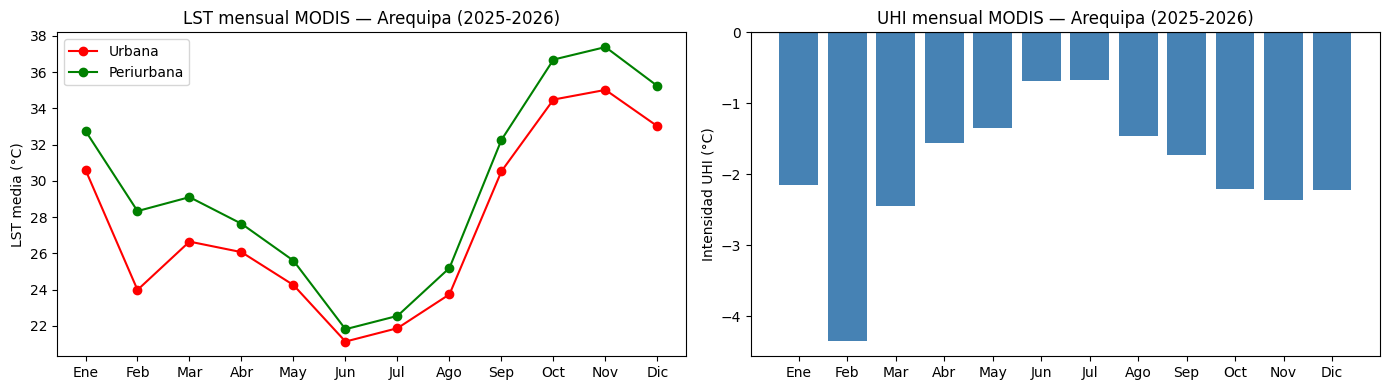

Mes más caliente (ciudad) : Nov
Mayor intensidad UHI      : Jul (-0.68 °C)


,mes,urb,peri,uhi
0,1,30.606737,32.755336,-2.148599
1,2,23.983597,28.331479,-4.347882
2,3,26.648577,29.101410,-2.452833
3,4,26.067173,27.633289,-1.566115
4,5,24.250935,25.596511,-1.345577
5,6,21.135716,21.815911,-0.680195
6,7,21.873063,22.551021,-0.677957
7,8,23.739925,25.195480,-1.455555
8,9,30.530467,32.261098,-1.730631
9,10,34.482177,36.687393,-2.205216


In [11]:
def procesar_modis(img):
    lst = (img.select("LST_Day_1km")
              .multiply(0.02)
              .subtract(273.15)
              .rename("LST_C"))
    qc = img.select("QC_Day")
    mascara = qc.bitwiseAnd(3).eq(0)
    return lst.updateMask(mascara).copyProperties(img, ["system:time_start"])

def uhi_mensual_modis(mes, anio_ini=2025, anio_fin=2026):
    col = (ee.ImageCollection("MODIS/061/MOD11A2")
           .filterBounds(provincia_arequipa)
           .filter(ee.Filter.calendarRange(mes, mes, "month"))
           .filter(ee.Filter.calendarRange(anio_ini, anio_fin, "year"))
           .map(procesar_modis)
           .mean())
    urb = (col.updateMask(urbano_mask)
           .reduceRegion(ee.Reducer.mean(), provincia_arequipa, 1000, maxPixels=1e10)
           .get("LST_C").getInfo())
    peri = (col.updateMask(periurbano_mask)
           .reduceRegion(ee.Reducer.mean(), provincia_arequipa, 1000, maxPixels=1e10)
           .get("LST_C").getInfo())
    return {"mes": mes, "urb": urb, "peri": peri,
            "uhi": (urb - peri) if urb is not None and peri is not None else None}

print("Calculando serie MODIS 2025-2026 (puede tomar 1-2 min)...")
res_modis = [uhi_mensual_modis(m) for m in range(1, 13)]
df_uhi = pd.DataFrame(res_modis)

meses_es = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1,13), df_uhi["urb"],  "ro-", label="Urbana")
axes[0].plot(range(1,13), df_uhi["peri"], "go-", label="Periurbana")
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(meses_es)
axes[0].set_ylabel("LST media (°C)"); axes[0].legend()
axes[0].set_title("LST mensual MODIS — Arequipa (2025-2026)")

axes[1].bar(range(1,13), df_uhi["uhi"],
            color=["salmon" if v and v > 0 else "steelblue" for v in df_uhi["uhi"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel("Intensidad UHI (°C)")
axes[1].set_title("UHI mensual MODIS — Arequipa (2025-2026)")
plt.tight_layout(); plt.show()

print(f"Mes más caliente (ciudad) : {meses_es[df_uhi['urb'].idxmax()]}")
print(f"Mayor intensidad UHI      : {meses_es[df_uhi['uhi'].idxmax()]} ({df_uhi['uhi'].max():.2f} °C)")
df_uhi

---
## 5. Comparación: ¿la UHI es positiva o negativa según estación? ¿Por qué?

Los resultados muestran que, a diferencia del patrón típico de ciudades cálidas, la Isla de Calor Urbana (UHI) en Arequipa es **negativa en ambas estaciones**: −2.23 °C en verano (35.62 °C urbano vs. 37.86 °C periurbano) y −1.45 °C en época seca (28.34 °C vs. 29.79 °C).
La serie mensual de MODIS confirma que la UHI se mantiene negativa los 12 meses del año, con su mayor magnitud en pleno verano (mínimo en **febrero, −4.35 °C**) y su menor magnitud durante el invierno seco (junio-julio, en torno a −0.68 °C).

Esto indica que en Arequipa es la **zona periurbana** la que se calienta más que la ciudad un patrón de "isla fría urbana" diurna, característico de ciudades áridas de altura. La explicación combina varios factores: (1) la zona periurbana (suelo no urbano según MapBiomas) está dominada por suelo desnudo, afloramientos rocosos y laderas volcánicas (Misti, Chachani), con muy baja cobertura vegetal y bajo albedo, que bajo la fuerte radiación solar de altura (2,335 m s.n.m., cielos muy despejados) se sobrecalientan durante el día; (2) el casco urbano concentra plazas y parques con riego, sombra de edificaciones y materiales como el sillar volcánico, que atenúan el calentamiento diurno frente a ese entorno árido expuesto. Este mecanismo es distinto al de Lima, donde la UHI negativa se explica por la neblina costera invernal, no por un contraste
suelo-desnudo/vegetación urbana.

La brecha es más amplia en verano que en época seca porque la radiación solar es más intensa y porque el sur andino recibe su temporada de lluvias entre diciembre y marzo: el suelo periurbano se humedece brevemente y luego se sobrecalienta con más fuerza que en invierno, cuando ambas zonas están secas y el contraste se reduce. Al comparar 2025 vs. 2026 (año FEN), el efecto es
más marcado en verano: la UHI pasó de −0.82 °C (2025) a −3.57 °C (2026), es decir, se cuadruplicó en magnitud consistente con años Niño, que suelen traer cielos más despejados y mayor insolación sobre el sur andino, intensificando el sobrecalentamiento de las superficies desnudas periurbanas. En época seca el cambio fue más leve y en sentido contrario (−1.69 °C en 2025 a −0.92 °C en 2026), lo que sugiere que el efecto FEN en Arequipa es principalmente estacional (concentrado en verano) y no un desplazamiento uniforme durante todo el año.


---
## 6. Conclusión: ¿Cómo se compara con Lima?

Arequipa comparte con Lima el signo negativo de la UHI, pero por una razón físicamente distinta
y con una dinámica estacional casi opuesta. En Lima, la UHI es positiva en verano y se vuelve
negativa en invierno, cuando la garúa y la neblina costera enfrían más al centro urbano que a
las áreas periurbanas. En Arequipa, en cambio, la UHI es negativa **todo el año**, y su magnitud
es mayor precisamente en verano (hasta −4.35 °C en febrero) y menor en época seca (~−0.68 °C):
el patrón estacional está invertido respecto a Lima.

En magnitud, la UHI de Arequipa (entre −0.7 °C y −4.3 °C según el mes) es comparable o incluso
mayor en valor absoluto que la de Lima en su estación más marcada, lo que muestra que el
contraste térmico ciudad-entorno puede ser tan fuerte en una ciudad andina árida como en una
costera, aunque el mecanismo sea otro: en Lima es la nubosidad marina estacional; en Arequipa es
el contraste de albedo y vegetación entre un núcleo urbano con riego y sombra, y una periferia de
suelo desnudo, rocoso y volcánico bajo fuerte radiación solar de altura.

Sobre la resolución de los sensores: Landsat (30 m) permite ver el patrón intraurbano con
detalle diferenciar centro histórico, avenidas o barrios periféricos, algo que MODIS (1 km) no
logra porque mezcla en un solo píxel zonas urbanas y no urbanas cercanas, suavizando el
contraste real. En este trabajo, Landsat fue clave para las tablas puntuales de verano/época
seca (entregables 2 y 3, con valores más extremos y realistas), mientras que MODIS aportó la
tendencia estacional continua a lo largo de los 12 meses (entregable 4) gracias a su alta
frecuencia temporal (compuestos de 8 días), algo que Landsat no puede igualar por su menor
frecuencia de paso.


---
### Preguntas guía (para apoyar tu análisis en las secciones 5 y 6)

-  **¿Tu ciudad también muestra UHI negativa en invierno, como Lima?**

Sí, pero a diferencia de Lima donde la UHI negativa aparece solo en invierno, en Arequipa la UHI es negativa durante **todo el año**, incluyendo el verano, donde de hecho alcanza su mayor magnitud negativa (hasta −4.35 °C en febrero).

- **¿En qué mes es mayor la intensidad UHI? ¿Coincide con la estación seca/lluviosa local?**

Febrero muestra la mayor intensidad (−4.35 °C), coincidiendo con pleno verano austral y la temporada de lluvias del sur andino (dic-mar). Curiosamente, esa temporada de lluvias no reduce la brecha térmica sino que la amplifica, probablemente por el sobrecalentamiento del suelo desnudo periurbano tras los eventos de lluvia.

- **¿Qué diferencias hay entre Landsat (30 m) y MODIS (1 km)? ¿Cuál muestra mejor el patrón intraurbano?**

Landsat, gracias a su resolución de 30 m, resuelve el detalle intraurbano (manzanas, avenidas, zonas industriales); MODIS, con píxeles de 1 km, mezcla zonas urbanas y periurbanas cercanas y por eso subestima el contraste real, aunque compensa con mayor frecuencia temporal (compuestosde 8 días), útil para ver la evolución mensual de la UHI a lo largo del año.
